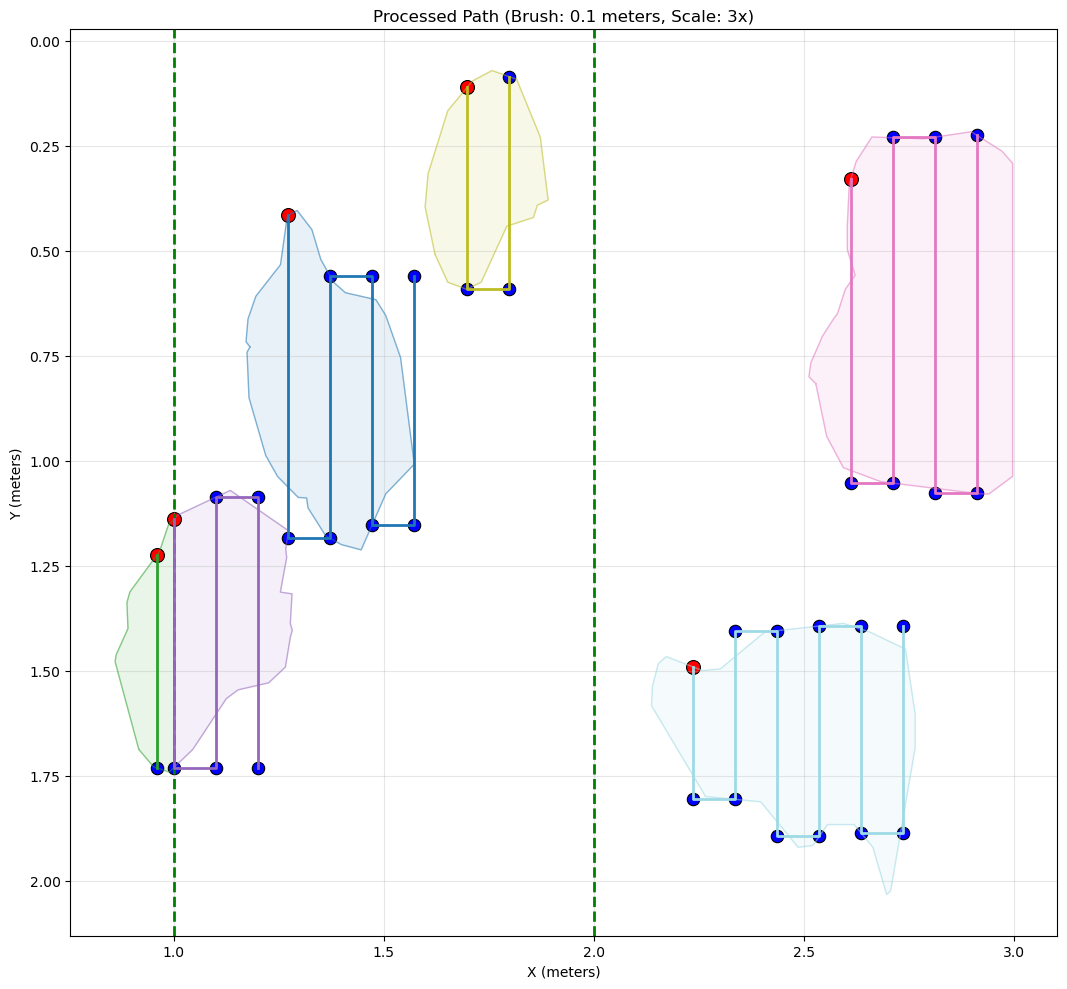

1 Middle 8 0.1 (1.272;0.416) (1.272;1.185) (1.372;1.185) (1.372;0.560) (1.472;0.560) (1.472;1.154) (1.572;1.154) (1.572;0.560)
2 Left 2 0.1 (0.960;1.224) (0.960;1.732)
3 Middle 6 0.1 (1.000;1.140) (1.000;1.731) (1.100;1.731) (1.100;1.087) (1.200;1.087) (1.200;1.731)
4 Right 8 0.1 (2.613;0.329) (2.613;1.054) (2.713;1.054) (2.713;0.230) (2.813;0.230) (2.813;1.078) (2.913;1.078) (2.913;0.225)
5 Middle 4 0.1 (1.698;0.111) (1.698;0.591) (1.798;0.591) (1.798;0.085)
6 Right 12 0.1 (2.238;1.492) (2.238;1.807) (2.338;1.807) (2.338;1.405) (2.438;1.405) (2.438;1.894) (2.538;1.894) (2.538;1.394) (2.638;1.394) (2.638;1.888) (2.738;1.888) (2.738;1.394)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split

# Глобальные параметры
IMAGE_SCALE_FACTOR = 3  # Масштаб для перевода пикселей в метры
BRUSH_RADIUS = 0.1        # Радиус щетки по умолчанию (в метрах)
SPLIT_1 = IMAGE_SCALE_FACTOR/3 #координата первой линии 
SPLIT_2 = (IMAGE_SCALE_FACTOR/3)*2#координата второй линии
SPLIT_LINES_X = [SPLIT_1, SPLIT_2]  # X-координаты разделительных линий (в метрах)

def unique_points(points):
    seen = set()
    return [p for p in points if not (p in seen or seen.add(p))]

def ensure_minimum_points(polygon_points):
    """Добавляет точки в полигон, если их меньше двух"""
    if len(polygon_points) >= 2:
        return polygon_points
    
    # Получаем границы полигона
    minx = min(p[0] for p in polygon_points) if polygon_points else 0
    maxx = max(p[0] for p in polygon_points) if polygon_points else 0
    miny = min(p[1] for p in polygon_points) if polygon_points else 0
    maxy = max(p[1] for p in polygon_points) if polygon_points else 0
    
    # Среднее по X
    mid_x = (minx + maxx) / 2
    
    # Если нет точек вообще - создаем две
    if len(polygon_points) == 0:
        return [(mid_x, miny), (mid_x, maxy)]
    
    # Если только одна точка - добавляем вторую
    if len(polygon_points) == 1:
        existing_point = polygon_points[0]
        if existing_point[1] > (miny + maxy) / 2:  # Если точка в верхней части
            return [existing_point, (mid_x, miny)]
        else:  # Если точка в нижней части
            return [existing_point, (mid_x, maxy)]
    
    return polygon_points

def adjust_last_point(points):
    """Корректирует последнюю точку маршрута, выравнивая её по Y с точкой за две позиции до неё"""
    if len(points) < 4:  # Нужно как минимум 4 точки для корректировки
        return points
    
    last_point = points[-1]
    reference_point = points[-4]  # Точка за три позиции до последней (так как индексы с 0)
    roll_point = points[-2]
    
    # Получаем y-координаты для сравнения
    last_y = last_point[1]
    ref_y = reference_point[1]
    roll_y = roll_point[1]
    
    if last_y > roll_y:  # точка снизу 
        if last_y > ref_y:
            return points
        else:
            adjusted_point = (last_point[0], ref_y)
    else: # точка сверху 
        if last_y > ref_y:
            adjusted_point = (last_point[0], ref_y)
        else:
            return points
            
    # Заменяем последнюю точку на скорректированную
    return points[:-1] + [adjusted_point]

def process_coordinates(path):
    x = 0
    if not path:
        return []
    
    path = unique_points(path)
    processed = [path[0]]
    
    for i in range(1, len(path), 2):
        if i + 1 >= len(path):
            processed.append(path[i])
            break
            
        point1, point2 = path[i], path[i + 1]
        x += 1
        
        if x % 2 == 1:
            y_val = point1[1] if point1[1] > point2[1] else point2[1]
            processed.extend([(point1[0], y_val), (point2[0], y_val)])
        else:
            y_val = point1[1] if point1[1] < point2[1] else point2[1]
            processed.extend([(point1[0], y_val), (point2[0], y_val)])
    
    # Применяем корректировку последней точки
    processed = adjust_last_point(processed)
    
    return processed

def parse_data(file_path):
    polygons = []
    current_polygon = []
    
    with open(file_path, 'r') as file:
        for line in file:
            if not line.strip(): continue
            data = line.strip().split()[1:]
            if not data: continue
            
            coords = list(map(float, data))
            # Масштабируем координаты с использованием глобального параметра
            coords_scaled = [c * IMAGE_SCALE_FACTOR for c in coords]
            current_polygon.extend(zip(coords_scaled[::2], coords_scaled[1::2]))
            
            if line.startswith('0'):
                if current_polygon:
                    # Обеспечиваем минимальное количество точек
                    current_polygon = ensure_minimum_points(current_polygon)
                    polygons.append(Polygon(current_polygon))
                    current_polygon = []
    
    if current_polygon:
        current_polygon = ensure_minimum_points(current_polygon)
        polygons.append(Polygon(current_polygon))
    
    return polygons

def create_vertical_lines(polygon, brush_radius):
    minx, miny, maxx, maxy = polygon.bounds
    lines = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += brush_radius
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                lines.append(geom)
        elif intersection.geom_type == 'LineString':
            lines.append(intersection)
        x += brush_radius
    return lines

def split_polygon_with_lines(polygon):
    result = [polygon]
    
    for split_x in SPLIT_LINES_X:
        split_line = LineString([(split_x, polygon.bounds[1]), (split_x, polygon.bounds[3])])
        temp = []
        
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= SPLIT_LINES_X[0]:
        return "Left"
    elif minx >= SPLIT_LINES_X[-1]:
        return "Right"
    else:
        return "Middle"

def generate_snake_path(points, brush_radius):
    if len(points) < 2:
        return []
    
    points = unique_points(points)
    
    upper = []
    lower = []
    for i in range(0, len(points), 2):
        if i+1 < len(points):
            lower.append(points[i])
            upper.append(points[i+1])
    
    path = []
    for i in range(len(upper)):
        if i % 2 == 0:
            path.append(lower[i])
            path.append(upper[i])
        else:
            path.append(upper[i])
            path.append(lower[i])
        
        if i < len(upper)-1:
            if i % 2 == 0:
                path.append((upper[i][0], upper[i][1]))
            else:
                path.append((lower[i][0], lower[i][1]))
    
    return path
    
def process_polygons(polygons, brush_radius):
    all_new_points = []
    split_polygons = []
    
    for polygon in polygons:
        split_polygons.extend(split_polygon_with_lines(polygon))
    
    for polygon_idx, polygon in enumerate(split_polygons):
        lines = create_vertical_lines(polygon, brush_radius)
        points = []
        
        for line in lines:
            coords = list(line.coords)
            points.extend(coords)
        
        if not points:
            continue
            
        grouped = {}
        for x, y in points:
            if x not in grouped:
                grouped[x] = []
            grouped[x].append(y)
        
        vertical_points = []
        for x in sorted(grouped.keys()):
            ys = sorted(grouped[x])
            vertical_points.append((x, ys[0]))
            vertical_points.append((x, ys[-1]))
        
        section = determine_section(polygon)
        all_new_points.append((section, polygon_idx + 1, vertical_points))
    
    return split_polygons, all_new_points

def plot_results(polygons, brush_radius, new_points_data):
    fig, ax = plt.subplots(figsize=(14, 10))
    colors = plt.get_cmap('tab20', len(polygons))
    
    for i, polygon in enumerate(polygons):
        if polygon.geom_type == 'Polygon' and not polygon.is_empty:
            x, y = polygon.exterior.xy
            ax.plot(x, y, color=colors(i), linewidth=1, alpha=0.5)
            ax.fill(x, y, color=colors(i), alpha=0.1)
    
    # Рисуем разделительные линии из глобальных параметров
    for split_x in SPLIT_LINES_X:
        ax.axvline(x=split_x, color='green', linestyle='--', linewidth=2)
    
    for i, (section, poly_idx, points) in enumerate(new_points_data):
        if not points: continue
        
        original_path = generate_snake_path(points, brush_radius)
        processed_path = process_coordinates(original_path)
        
        if len(processed_path) > 1:
            x, y = zip(*processed_path)
            ax.plot(x, y, color=colors(i), linestyle='-', linewidth=2)
        
        for j, (x_p, y_p) in enumerate(processed_path):
            color = 'red' if j == 0 else 'blue'
            ax.scatter(x_p, y_p, color=color, s=100 if j == 0 else 80,
                       marker='o', edgecolors='black', linewidths=0.8)
    
    ax.set_aspect('equal')
    plt.xlabel('X (meters)')
    plt.ylabel('Y (meters)')
    plt.title(f'Processed Path (Brush: {brush_radius} meters, Scale: {IMAGE_SCALE_FACTOR}x)')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Основной код
if __name__ == "__main__":
    file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f2_150_jpg.rf.3b9c8f231bbd0024ddf48f1b687c9e8e.txt'
    
    polygons = parse_data(file_path)
    split_polygons, new_points_data = process_polygons(polygons, BRUSH_RADIUS)

    if split_polygons:
        plot_results(split_polygons, BRUSH_RADIUS, new_points_data)
        
        for section, poly_idx, points in new_points_data:
            original_path = generate_snake_path(points, BRUSH_RADIUS)
            if not original_path: continue
            
            processed_path = process_coordinates(original_path)
            coords_str = " ".join(f"({x:.3f};{y:.3f})" for x, y in processed_path)
            print(f"{poly_idx} {section} {len(processed_path)} {BRUSH_RADIUS} {coords_str}")
    else:
        print("Нет полигонов для отображения")

Creating colored polygons plot...


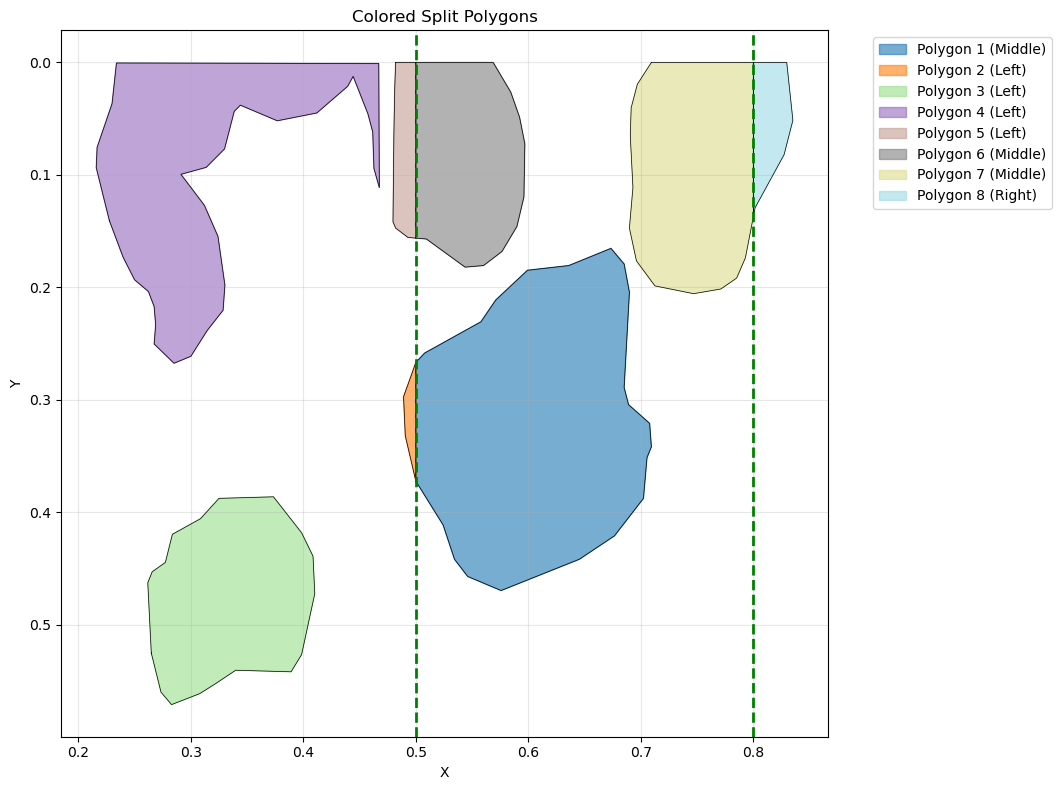

Enter brush radius:  0.03
